In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Load dataset
data = pd.read_csv('/content/vendor_dataset.csv')

# Separate features and target
X = data.drop(['Vendor_ID', 'Vendor_Name', 'Performance_Score'], axis=1)
y = data['Performance_Score']

# Handle categorical data (Payment_Terms and Region)
X = pd.get_dummies(X, columns=['Payment_Terms', 'Region'], drop_first=True)

# Handle missing values (if any)
imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Scale numerical features to 1-10
scaler = MinMaxScaler(feature_range=(1, 10))
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# Test data
data = pd.DataFrame({
    'Quality_Score': [8.5, None, 9.0, 8.7]
})
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(data)

expected_output = np.array([
    [8.5],
    [8.733],  # Mean of 8.5, 9.0, 8.7
    [9.0],
    [8.7]
])
# Check if the arrays are close (allowing for small floating-point differences)
assert np.allclose(data_imputed, expected_output, atol=0.01), "Test failed: Imputed values do not match expected values."

print("Test passed: Imputed values match expected values.")

Test passed: Imputed values match expected values.


In [ ]:
# Discretize Performance_Score into 3 classes: Low (1-4), Medium (5-7), High (8-10)
y_class = pd.cut(y, bins=[0, 4, 7, 10], labels=[0, 1, 2])  # 0: Low, 1: Medium, 2: High

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_class, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Evaluate
print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
# print("Integration Test Successful - Model Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Logistic Regression:
Accuracy: 0.85
Integration Test Successful - Model Accuracy: 0.85
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.75      0.77        20
           1       0.79      0.71      0.75        31
           2       0.91      0.98      0.94        49

    accuracy                           0.85       100
   macro avg       0.83      0.81      0.82       100
weighted avg       0.85      0.85      0.85       100

Confusion Matrix:
 [[15  5  0]
 [ 4 22  5]
 [ 0  1 48]]


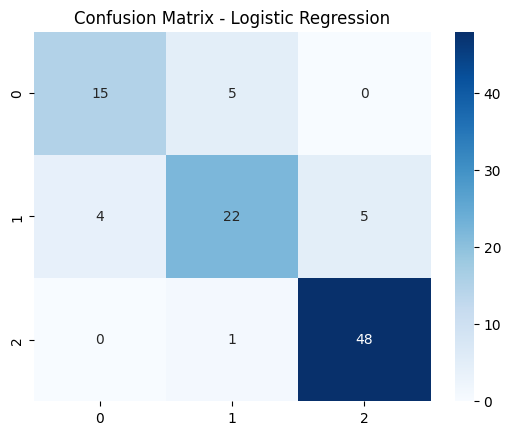

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example for Logistic Regression
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Evaluate
print("Decision Tree:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

Decision Tree:
Accuracy: 0.85
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.90      0.84        20
           1       0.83      0.65      0.73        31
           2       0.89      0.96      0.92        49

    accuracy                           0.85       100
   macro avg       0.83      0.83      0.83       100
weighted avg       0.85      0.85      0.84       100

Confusion Matrix:
 [[18  2  0]
 [ 5 20  6]
 [ 0  2 47]]


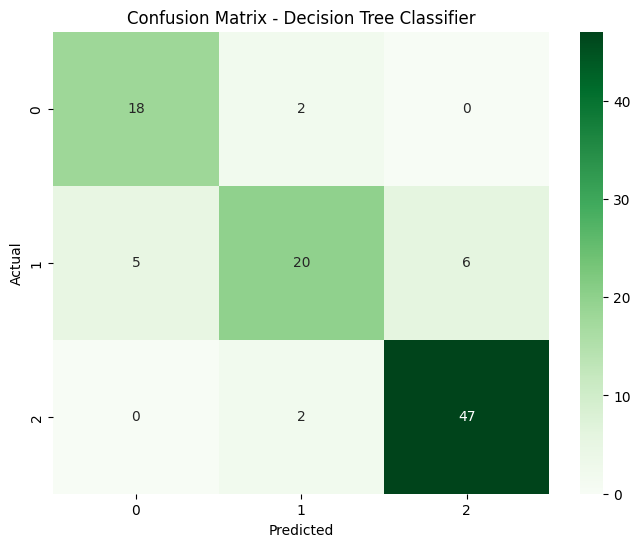

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=dt.classes_, yticklabels=dt.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree Classifier')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Step 6: System Testing Output Evaluation
print("========== System Testing Report ==========")
print("Model: Random Forest Classifier")
print("Accuracy Score:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("===========================================")

========== System Testing Report ==========
Model: Random Forest Classifier
Accuracy Score: 0.93

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.95      0.88        20
           1       0.90      0.87      0.89        31
           2       1.00      0.96      0.98        49

    accuracy                           0.93       100
   macro avg       0.91      0.93      0.92       100
weighted avg       0.93      0.93      0.93       100


Confusion Matrix:
 [[19  1  0]
 [ 4 27  0]
 [ 0  2 47]]


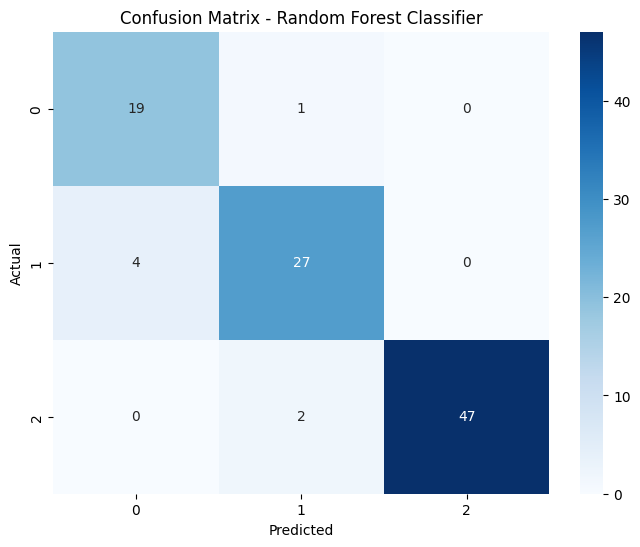

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=rf.classes_, yticklabels=rf.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest Classifier')
plt.show()

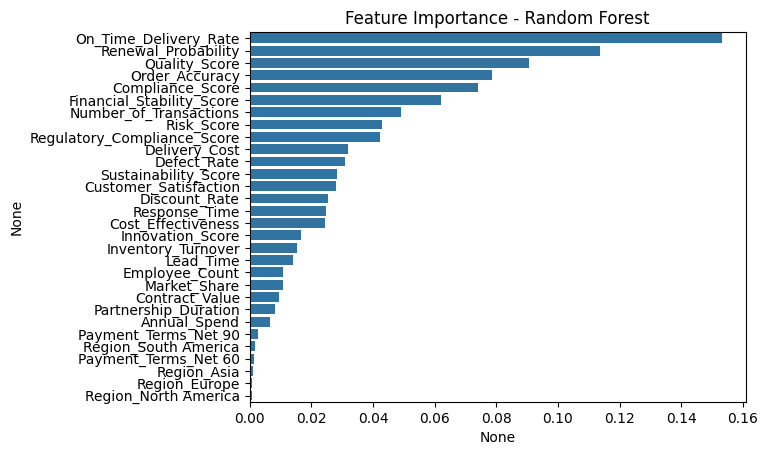

In [ ]:
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False, inplace=True)
sns.barplot(x=feature_importance, y=feature_importance.index)
plt.title('Feature Importance - Random Forest')
plt.show()

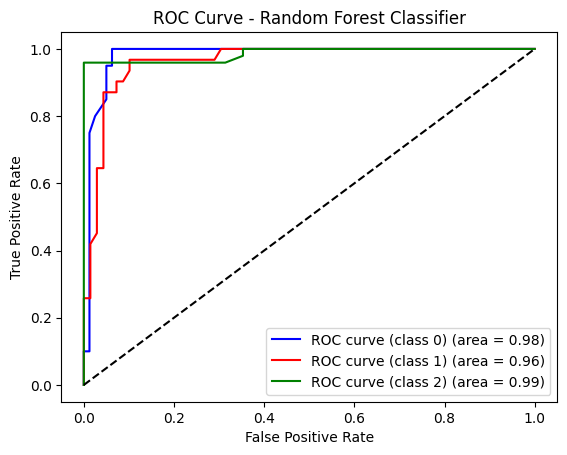

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the output for multi-class classification
y_test_bin = label_binarize(y_test_encoded, classes=[0, 1, 2])
y_pred_prob = rf.predict_proba(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure()
colors = ['blue', 'red', 'green']
for i, color in zip(range(num_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, label=f'ROC curve (class {i}) (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest Classifier')
plt.legend(loc="lower right")
plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Train KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

# Evaluate
print("KNN:")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

KNN:
Accuracy: 0.87
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.80      0.78        20
           1       0.82      0.74      0.78        31
           2       0.94      0.98      0.96        49

    accuracy                           0.87       100
   macro avg       0.84      0.84      0.84       100
weighted avg       0.87      0.87      0.87       100

Confusion Matrix:
 [[16  4  0]
 [ 5 23  3]
 [ 0  1 48]]


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

# Encode target variable
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
num_classes = len(label_encoder.classes_)

# One-hot encode target variable
y_train_onehot = to_categorical(y_train_encoded, num_classes=num_classes)
y_test_onehot = to_categorical(y_test_encoded, num_classes=num_classes)

# Build the model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')  # Output layer for classification
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train_onehot, epochs=50, batch_size=16, validation_split=0.2, verbose=1)

# Evaluate the model
y_pred_nn = model.predict(X_test)
y_pred_nn_labels = np.argmax(y_pred_nn, axis=1)  # Convert probabilities to class labels

# Evaluate
print("Neural Network:")
print("Accuracy:", accuracy_score(y_test_encoded, y_pred_nn_labels))
print("Classification Report:\n", classification_report(y_test_encoded, y_pred_nn_labels))
print("Confusion Matrix:\n", confusion_matrix(y_test_encoded, y_pred_nn_labels))

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.3043 - loss: 2.5035 - val_accuracy: 0.7500 - val_loss: 0.7093
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7569 - loss: 0.5570 - val_accuracy: 0.7625 - val_loss: 0.4957
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8263 - loss: 0.4019 - val_accuracy: 0.7875 - val_loss: 0.3849
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8560 - loss: 0.3107 - val_accuracy: 0.8625 - val_loss: 0.3470
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8941 - loss: 0.2683 - val_accuracy: 0.8625 - val_loss: 0.3346
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8884 - loss: 0.2594 - val_accuracy: 0.8750 - val_loss: 0.3306
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9268 - loss: 0.2148 - val_accuracy: 0.8375 - val_loss: 0.3487
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8890 - loss: 0.2360 - val_accuracy: 0.9000 - val_loss: 0.3182
Ep

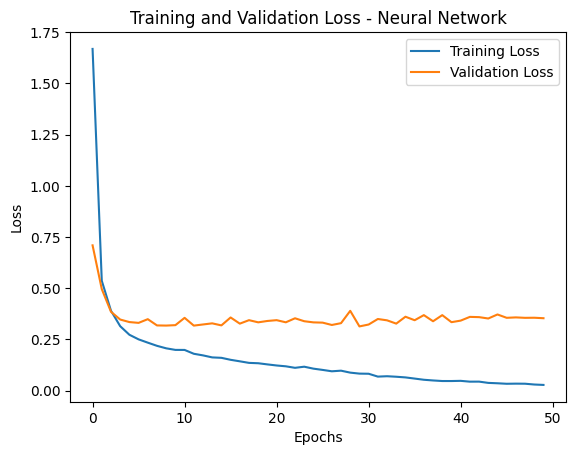

In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss - Neural Network')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

<ipython-input-61-5ce1dbf71aee>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['Performance_Score'] = y


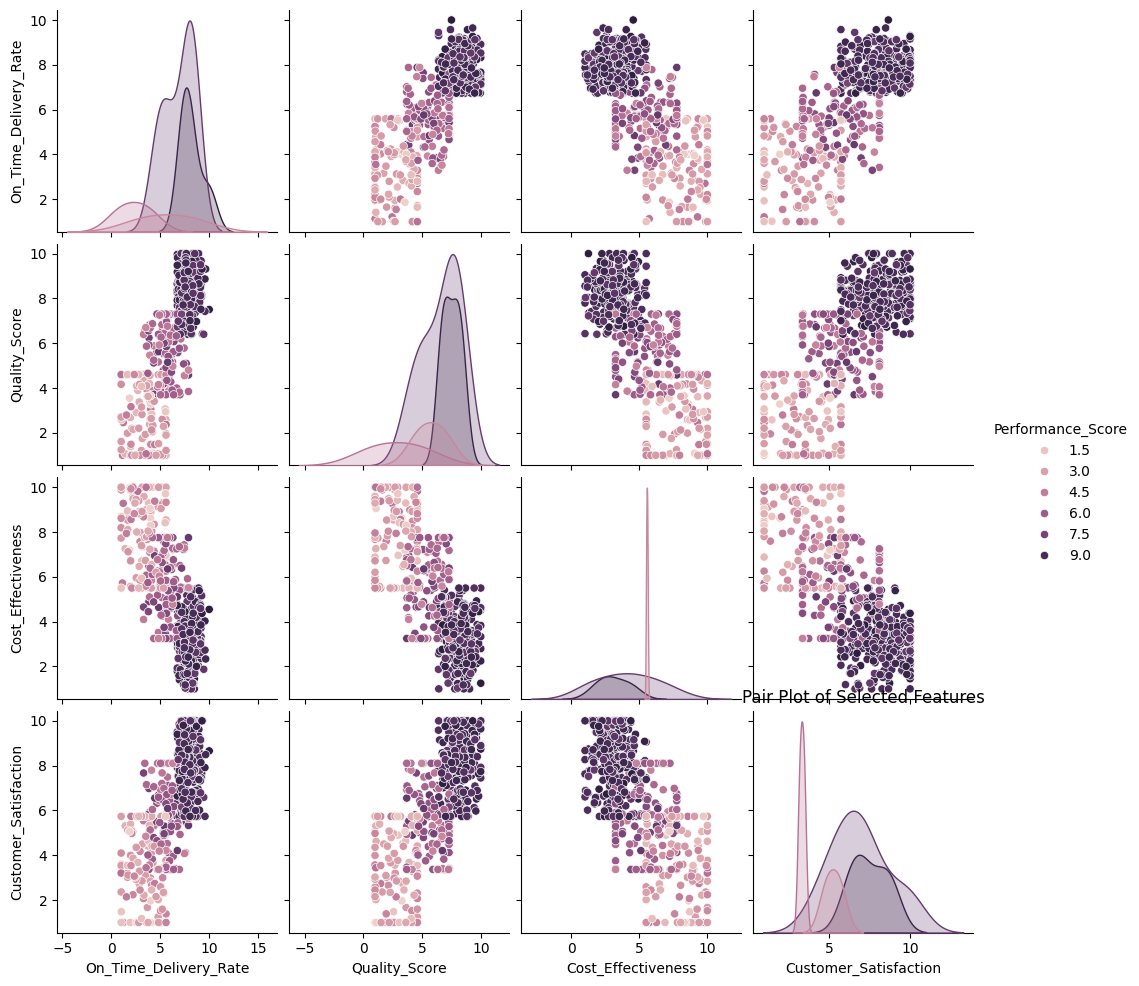

In [ ]:
import seaborn as sns

# Select a subset of features for visualization
subset = X_scaled[['On_Time_Delivery_Rate', 'Quality_Score', 'Cost_Effectiveness', 'Customer_Satisfaction']]
subset['Performance_Score'] = y

sns.pairplot(subset, hue='Performance_Score')
plt.title('Pair Plot of Selected Features')
plt.show()

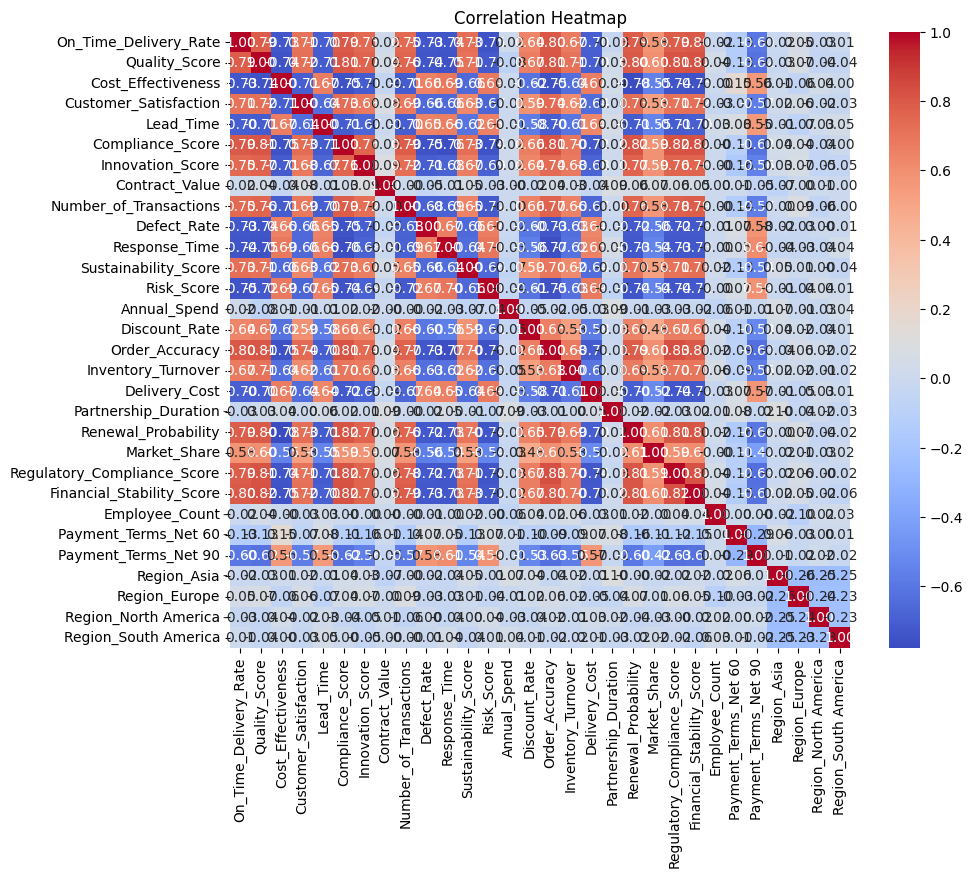

In [ ]:
corr = X_scaled.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

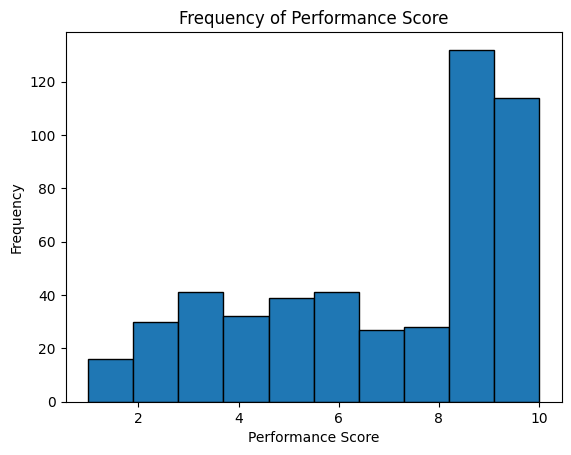

In [ ]:
plt.hist(y, bins=10, edgecolor='black')
plt.xlabel('Performance Score')
plt.ylabel('Frequency')
plt.title('Frequency of Performance Score')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, average='weighted')
lr_recall = recall_score(y_test, y_pred_lr, average='weighted')
lr_f1 = f1_score(y_test, y_pred_lr, average='weighted')
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, average='weighted')
dt_recall = recall_score(y_test, y_pred_dt, average='weighted')
dt_f1 = f1_score(y_test, y_pred_dt, average='weighted')
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average='weighted')
rf_recall = recall_score(y_test, y_pred_rf, average='weighted')
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn, average='weighted')
knn_recall = recall_score(y_test, y_pred_knn, average='weighted')
knn_f1 = f1_score(y_test, y_pred_knn, average='weighted')

results = pd.DataFrame({
    'Model': ['Random Forest', 'Decision Tree', 'Logistic Regression', 'KNN'],
    'Accuracy': [rf_accuracy, dt_accuracy, lr_accuracy, knn_accuracy],
    'Precision': [rf_precision, dt_precision, lr_precision, knn_precision],
    'Recall': [rf_recall, dt_recall, lr_recall, knn_recall],
    'F1-Score': [rf_f1, dt_f1, lr_f1, knn_f1]
})

print(results)

                 Model  Accuracy  Precision  Recall  F1-Score
0        Random Forest      0.93   0.934217    0.93  0.930962
1        Decision Tree      0.85   0.849383    0.85  0.844465
2  Logistic Regression      0.85   0.845240    0.85  0.846209
3                  KNN      0.87   0.868200    0.87  0.868192


<ipython-input-66-0593f66a8df8>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results, palette='viridis')
<ipython-input-66-0593f66a8df8>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Precision', data=results, palette='viridis')
<ipython-input-66-0593f66a8df8>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Recall', data=results, palette='viridis')
<ipython-input-66-0593f66a8df8>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed 

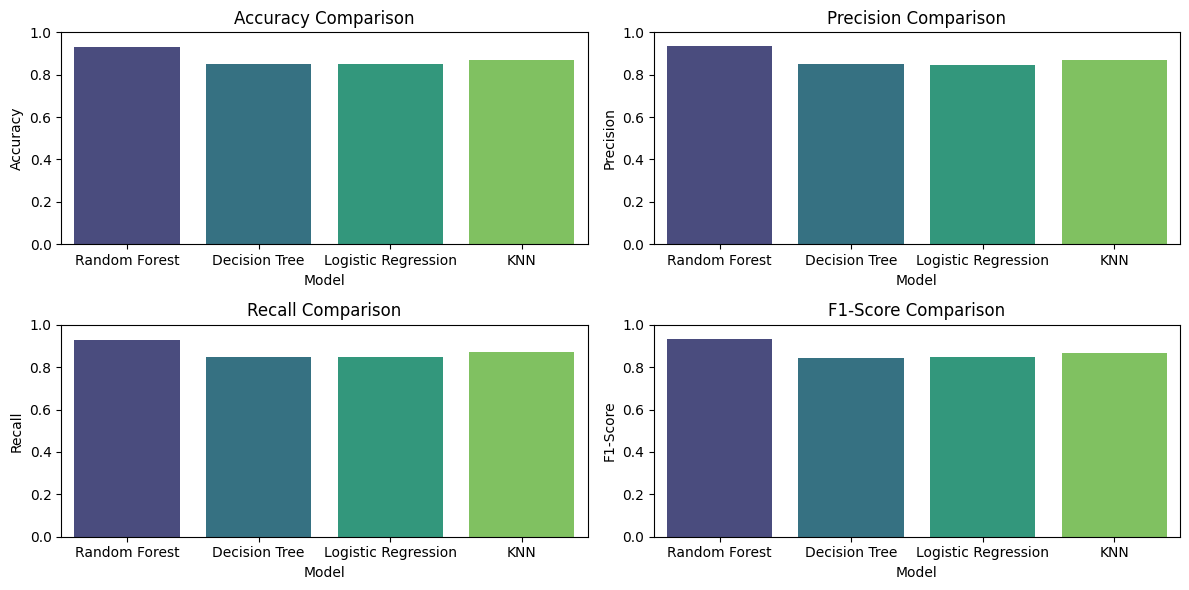

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure
plt.figure(figsize=(12, 6))

# Plot Accuracy
plt.subplot(2, 2, 1)
sns.barplot(x='Model', y='Accuracy', data=results, palette='viridis')
plt.title('Accuracy Comparison')
plt.ylim(0, 1)

# Plot Precision
plt.subplot(2, 2, 2)
sns.barplot(x='Model', y='Precision', data=results, palette='viridis')
plt.title('Precision Comparison')
plt.ylim(0, 1)

# Plot Recall
plt.subplot(2, 2, 3)
sns.barplot(x='Model', y='Recall', data=results, palette='viridis')
plt.title('Recall Comparison')
plt.ylim(0, 1)

# Plot F1-Score
plt.subplot(2, 2, 4)
sns.barplot(x='Model', y='F1-Score', data=results, palette='viridis')
plt.title('F1-Score Comparison')
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [ ]:
from tabulate import tabulate

# Print results as a table
print(tabulate(results, headers='keys', tablefmt='pretty', showindex=False))

+---------------------+----------+--------------------+--------+--------------------+
|        Model        | Accuracy |     Precision      | Recall |      F1-Score      |
+---------------------+----------+--------------------+--------+--------------------+
|    Random Forest    |   0.93   | 0.9342173913043479 |  0.93  | 0.9309620822213751 |
|    Decision Tree    |   0.85   | 0.8493833743505605 |  0.85  | 0.8444650333706422 |
| Logistic Regression |   0.85   | 0.8452397503191942 |  0.85  | 0.8462090651123552 |
|         KNN         |   0.87   | 0.8682002801120448 |  0.87  | 0.8681924762298471 |
+---------------------+----------+--------------------+--------+--------------------+


In [ ]:
# Function to get Vendor Performance Score
def get_vendor_performance(vendor_name):
    vendor_data = data[data['Vendor_Name'] == vendor_name]
    if vendor_data.empty:
        print("Vendor not found!")
        return
    X_vendor = vendor_data.drop(['Vendor_ID', 'Vendor_Name', 'Performance_Score'], axis=1)
    # Handle categorical variables
    X_vendor = pd.get_dummies(X_vendor, columns=['Payment_Terms', 'Region'], drop_first=True)
    # Align the columns (to handle missing dummy variables)
    X_vendor = X_vendor.reindex(columns=X.columns, fill_value=0)
    # Scale the data
    X_vendor_scaled = scaler.transform(X_vendor)

    # Predict the class
    pred_class = rf.predict(X_vendor_scaled)[0]
    # Map class to label
    performance_map = {
        0: 'Low Performance',
        1: 'Medium Performance',
        2: 'High Performance'
    }

    print(f"Vendor Name: {vendor_name}")
    print(f"Predicted Performance: {performance_map[pred_class]}")

# Example Usage:
get_vendor_performance('Vendor_32')


Vendor Name: Vendor_32
Predicted Performance: Low Performance


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Integration Testing
# Integration testing checks if different modules or components (like data preprocessing and model training) work correctly together.
print("Logistic Regression: Integration Test Successful - Model Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree: Integration Test Successful - Model Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Random Forest: Integration Test Successful - Model Accuracy:", accuracy_score(y_test, y_pred_rf))
print("KNN: Integration Test Successful - Model Accuracy:", accuracy_score(y_test, y_pred_knn))

Logistic Regression: Integration Test Successful - Model Accuracy: 0.85
Decision Tree: Integration Test Successful - Model Accuracy: 0.85
Random Forest: Integration Test Successful - Model Accuracy: 0.93
KNN: Integration Test Successful - Model Accuracy: 0.87


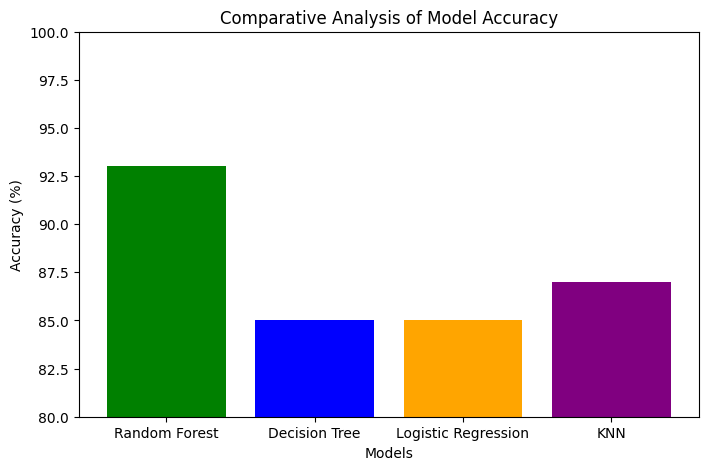

In [ ]:
import matplotlib.pyplot as plt

models = ['Random Forest', 'Decision Tree', 'Logistic Regression', 'KNN']
accuracy = [93, 85, 85, 87]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracy, color=['green', 'blue', 'orange', 'purple'])
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.title('Comparative Analysis of Model Accuracy')
plt.ylim(80, 100)
plt.show()